# DMRG Single site 

In [1]:
include("./dmrg_helper_functions.jl")

Main.DMRGHelperFunctions

NOTE: we are including a module containing some functions that will be used in the notebook.

In [2]:
using Pkg
Pkg.activate("..")
using ITensors
using ITensorMPS
using LinearAlgebra
using Test
using Printf
using .DMRGHelperFunctions #this carries the functions defined in the included module into the current namespace, so that we can call them without the module prefix.

  Activating project at `~/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks`


Here we define a first, simple and highly unoptimized version of the single site DMRG algorithm.

## Definition of the system

As customary in these exploratory notebooks we use systems of spin-$1/2$ particles. Let's start simple. 

In [3]:
nn = 20
system = siteinds("S=1/2", nn);

Let us consider the familiar Heisenberg Hamiltonian, in the absence of a magnetic field:

$$
H_\text{heis} = -J \sum_{j=1}^{n-1}(\sigma_j^-\sigma_{j+1}^+ + \sigma_j^+\sigma_{j+1}^- + g \sigma_j^z \sigma_{j+1}^z)
$$
for $J=1.0$ and $g=1/2$.
Physically speaking:
- The "kinetic" terms $\sigma_j^-\sigma_{j+1}^+ + \text{H.c.}$ has a ground state that lives in the half-filled variety. This can be understood starting from the analytic solution of the $XY$ Hamiltonian 
$$
-J \sum_{j=1}^{n-1}(\sigma_j^-\sigma_{j+1}^+ + \sigma_j^+\sigma_{j+1}^-),
$$
in the single excitation subspace; the eigenvalues for the single excitation subspace are
$$
\epsilon_k = -2J \cos\left (\frac{k \pi}{n+1} \right)
$$
so that $\epsilon_0$ is the ground state energy, and $\ket{\epsilon_0}$ the corresponding eigenstate. If we indicate by $c_k^\dagger$ the operator $\ket{\epsilon_k}\bra{0}$ where $\ket{0}$ is the vacuum state (all spins down), then
$$
 \ket{\epsilon_k} = c_k^\dagger \ket{0}
 $$ 
 will create an eigenstate in the single excitation sector, while $c_k^\dagger c_j^\dagger \ket{0}$, with $k \neq j$ will create an eigenstate in the two-excitation sector and so on with energy $\epsilon_k + \epsilon_j$. The ground state of the $XY$ Hamiltonian is thus obtained by applying all the $c_k\dagger$ that add negative energy. It is thus clear that the ground state is determined as
$$
\ket{\text{GS}} = \prod_{k:\epsilon_k <0} c_k^\dagger \ket{0}
$$
which is a state living in the half-filled variety ($N_z \approx n/2$) variety of the Hilbert space. The corresponding ground state energy is

$$ E_G = \sum_{\epsilon_k < 0} \epsilon_k.$$

- The "magnetic" terms $J g \sigma_j^z \sigma_{j+1}^z$, on the other side, will favor all aligned ($\ket{\uparrow \uparrow}$ or $\ket{\downarrow \downarrow}$) or anti-aligned ($\ket{\uparrow \downarrow}$ or $\ket{\downarrow \uparrow}$) neighboring pairs depending on the sign of $J g$. If $Jg > 0$ aligned terms contribute negatively to the energy whereas if $J g < 0$ anti-aligned terms will be energetically favored (mind the $-$ in front of the Hamiltonian).

In the Heisenberg Hamiltonian, the "kinetic" and "magnetic" terms are in competition and the relative values of $J$ and $g$ determine what kind of configuration the ground state will have. We refer to any textbook on solid state (quantum) physics for a detailed discussion. Here we limit ourselves to observe that:

- If $|g| \gg 1$ ($g$ large) the magnetic term will dominate, and the ground state would be an aligned/anti-aligned state depend on the sign of $g J$.  
- If $|g| \ll 1$ ($g$ small) the kinetic term will dominate, and the ground state will be close to the eigenstate of the $XY$ Hamiltonian
- if $|g| \approx$, the competition will result in some intermediate configuration.

This gives rise to a rich, and most intersting phase diagram, that has a correspondence to the behavior of the bond dimension of the corresponding ground states. 

In [4]:
jj = 1.0
g = 30.0
opsum = OpSum()
for j in 1:nn-1
    opsum += -jj , "S-", j, "S+", j+1
    opsum += -jj, "S+", j, "S-", j+1
end
for j in 1:nn-1
    opsum += -g * jj,"Z", j, "Z", j+1
end
ham = MPO(opsum, system);

With this values of the $J$ and $g$ parameters, $g \gg 1$ and $J g >0$, we are in the ferromagnetic phase;  the ground state will be thus  close to the aligned configuration $\ket{\uparrow \uparrow \ldots \uparrow}$ or $\ket{\downarrow \downarrow \ldots \downarrow}$ (the ground state is degenerate). Since $g \gg J$ we can estimate the ground state energy to be $E_g \approx -g \cdot (n-1) = -570$. 

In [5]:
bond_dim = 32
psi0 = random_mps(ComplexF64, system, linkdims=bond_dim)
orthogonalize!(psi0, 1)
H = ham
N = length(psi0)
psi = copy(psi0)
#R = build_right_blocks(psi, H)
#L = Vector{ITensor}(undef, N)  # L[k] viene riempito on-the-fly
maxdim::Int=100
cutoff::Float64=1e-14
tol_davidson::Float64=1e-14
maxiter_davidson::Int=50
E = 0.0

energies = Float64[]
bestState = copy(psi0)
norms = Float64[]
min_energy::Float64 = Inf
pos_min_energy::Int = 0

fileout = open("dmrg_single_site_output.txt", "w")

nsweeps = 30

for sweep in 1:nsweeps

    println("Sweep: $sweep")
    # ── Sweep L -> R ──────────────────────────────────────────
    # ── Reconstruct right blocks starting from the right. Right blocks are not changed during a L -> R  sweep ──
    R = build_right_blocks(psi, H)
    
    # Left blocks are built on the finally
    L = Vector{ITensor}(undef, N)

    #Inline definition of the apply_H function for the Davidson algorithm
    #Scope: visible within the loop, can access L and R which are updated at each iteration
    
    #Left-sweep: k=1,...,N-1
    for k in 1:N-1
        apply_H = v -> begin
            Hv = v * H[k]
            if k > 1; Hv = Hv * L[k-1]; end
            Hv = Hv * R[k+1]
            noprime(Hv)
        end

        println(fileout,"L->R: Updating site $k sweep $sweep")
        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #psi[k] updated. The overall dimension chi_{k-1} x d_k x chi_{k} of the output is the same as the input.
        #Now we need to shift the orthogonality center to k+1, which means:
        #psi[k] -> left-orthogonal 
        #psi[k+1] -> OC

        #Determine the left indices to perform the SVD. For k=1 we have only the physical index, while for k>1 we have both the left link and the physical index.
        #Note: linkind(psi, k-1) is the left link index of psi[k], while siteind(psi, k) is the physical index of psi[k]. The SVD will be performed by grouping these indices together as "left" indices, and the remaining right link index (if k>1) will be the "right" index.
        linds = (k == 1) ? [siteind(psi, k)] :
                           [linkind(psi, k-1), siteind(psi, k)]

        #Perform the SVD
        #We set cutoff=0 to keep all the singular values The lefttags argument is used to tag the left link index of U with "Link,l=k", which will be useful for the next iteration when we need to identify this index.
        #Note that we assign tags to the left and right link indices of U,S, and V, which will be useful for the next iteration when we need to identify these indices after the shift of the OC is completed. 
        U, S, V = svd(psi[k], linds; cutoff=0,
                      lefttags="Link,l=$k",righttags="Link,l=$k")
        #psi[k] is now left-orthogonal, while psi[k+1] is updated to be the new OC tensor by contracting S and V with the old psi[k+1]
        psi[k]   = U
        psi[k+1] = S * dag(V) * psi[k+1]

        #We update(actually assign) the left block L[k] on-the-fly using the updated psi[k]. This is possible because L[k] depends only on psi[1],...,psi[k], which are all updated at this point. In this way we avoid to reconstruct the left blocks from scratch at each iteration, which would be more expensive.
        L[k] = (k == 1) ?
            psi[k] * H[k] * dag(prime(psi[k])) :
            L[k-1] * psi[k] * H[k] * dag(prime(psi[k]))
    end #L->R sweep
    
    println(fileout,"After L->R sweep, sweep = $sweep, E = $E")

    #After the end of L->R we have all the L blocks L[1],...,L[N-1] updated.  The site N is the OC, and it will be updated during the R->L sweep.
#     # ── Sweep R -> L ──────────────────────────────────────────

# The blocks R[k],k=N,N-1,2 are built on the fly after the update of psi[k] during the R->L sweep, starting from the rightmost site. This is possible because R[k] depends only on psi[k],...,psi[N].

R = Vector{ITensor}(undef, N)


    for k in N:-1:2

        println(fileout,"R->L: Updating site $k sweep $sweep")
        apply_H = v -> begin
            Hv = v * H[k]
            if k < N; Hv = Hv * R[k+1]; end
            Hv = Hv * L[k-1]
            noprime(Hv)
        end


        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #Treat the site index and the right link index of psi[k] as "row" indices for the SVD.
        rinds = (k == N) ? [siteind(psi, k)] :                        
        [siteind(psi, k), linkind(psi, k)]
        
        #Perform the SVD to shift the OC to the left. Note that for k=N we have only the physical index, while for k<N we have both the physical index and the right link index.

        U, S, V = svd(psi[k], rinds;  cutoff=0,lefttags="Link,l=$(k-1)",righttags="Link,l=$(k-1)")

        psi[k]   = U
        psi[k-1] = psi[k-1] * S * dag(V)


        # build R[k] with updated psi[k]
        R[k] = (k==N) ? psi[k] * H[k] * dag(prime(psi[k])) : psi[k] * H[k] * dag(prime(psi[k])) * R[k+1]
               

    end #End of R->L sweep
    flush(fileout)
    en = real(inner(psi', ham, psi))
    @printf("sweep = %d | E = %.12f | maxdim = %d\n",
             sweep, en, maxlinkdim(psi))
    
    #store intermediate energies and states
    push!(energies, en)
    push!(norms, norm(psi))
    if en < min_energy
        min_energy = en
        pos_min_energy = sweep
        bestState = copy(psi)
        end
end

close(fileout)
         

Sweep: 1
sweep = 1 | E = -569.997597136713 | maxdim = 32
Sweep: 2
sweep = 2 | E = -569.999438641098 | maxdim = 32
Sweep: 3
sweep = 3 | E = -569.982823015008 | maxdim = 32
Sweep: 4
sweep = 4 | E = -569.991010554349 | maxdim = 32
Sweep: 5
sweep = 5 | E = -569.852320080579 | maxdim = 32
Sweep: 6
sweep = 6 | E = -569.377582306163 | maxdim = 32
Sweep: 7
sweep = 7 | E = -568.508770506396 | maxdim = 32
Sweep: 8
sweep = 8 | E = -565.214364374151 | maxdim = 32
Sweep: 9
sweep = 9 | E = -569.999893111820 | maxdim = 32
Sweep: 10
sweep = 10 | E = -569.999987705395 | maxdim = 32
Sweep: 11
sweep = 11 | E = -569.138770157736 | maxdim = 32
Sweep: 12
sweep = 12 | E = -560.347796619912 | maxdim = 32
Sweep: 13
sweep = 13 | E = -562.433248915795 | maxdim = 32
Sweep: 14
sweep = 14 | E = -569.999946099135 | maxdim = 32
Sweep: 15
sweep = 15 | E = -569.998965998840 | maxdim = 32
Sweep: 16
sweep = 16 | E = -567.435315340868 | maxdim = 32
Sweep: 17
sweep = 17 | E = -569.996214274037 | maxdim = 32
Sweep: 18
sweep

Find the best solution with current bond dimension

In [6]:
using Plots

In [7]:
sum(energies)/length(energies)

-566.8532968397225

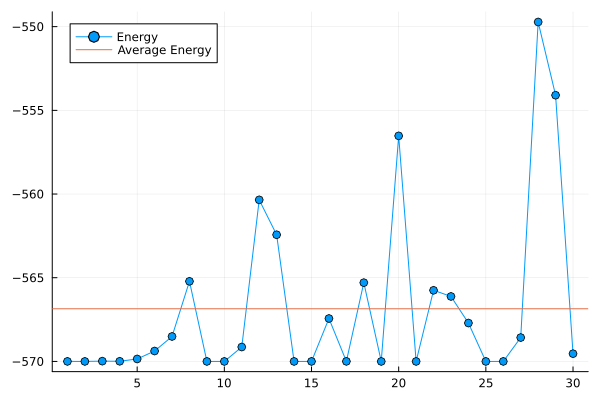

In [8]:
plot(energies, marker=:o, label="Energy")
hline!([sum(energies)/length(energies)], label="Average Energy")

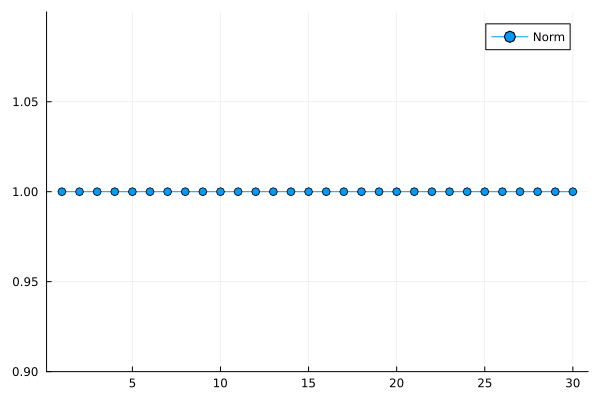

In [9]:
plot(norms, marker=:o, label="Norm",ylims=(0.9,1.1))

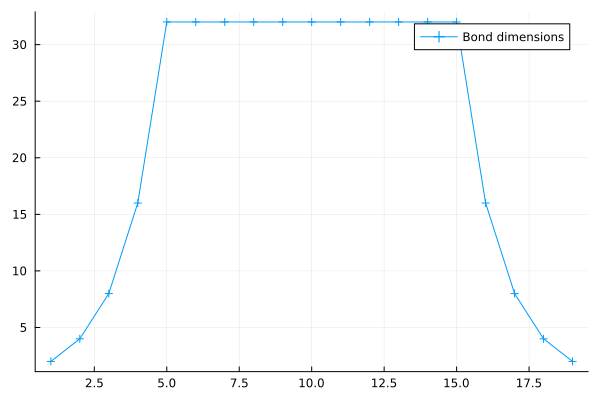

In [11]:
bondDims=[linkdim(bestState, k) for k in 1:N-1]
plot(bondDims, marker=:+, label="Bond dimensions")

We can inspect the properties of the best solution determined by DMRG, i.e. `bestState`.

First of all, we measure the average number of up spins.

In [15]:
appoTotS = OpSum()
for j in 1:nn
    appoTotS +=  "ProjUp", j
end
totS = MPO(appoTotS, system);

In [17]:
real(inner(psi', ham, psi))

0.00555299915655536

From this we can understand that the solution found by DMRG is $\approx \ket{\downarrow \downarrow \ldots \downarrow}$.

We can then measure the correlation between couples $(i,j), i>j$ of sites.

In [19]:
function get_correlations(psi::MPS, i::Int, j::Int, opi::String,opj::String)
    #We compute the correlation <S+_i S-_j> as the contraction of the MPS psi with the MPO corresponding to the operator S+_i S-_j, which is built as an OpSum and then converted to an MPO. The function returns a complex number, which is the value of the correlation.
    opsum = OpSum()
    opsum += opi, i, opj, j
    opMPO = MPO(opsum, system)
    return inner(psi', opMPO, psi)
end

get_correlations (generic function with 1 method)

In [28]:
zzCorrelations = [[(i>j ? get_correlations(psi, i, j, "Z", "Z") : 0.) for j=1:nn] for i=2:nn]

19-element Vector{Vector{Number}}:
 [0.9999997393195651 - 4.697743831988827e-16im, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.9951183000175083 + 2.1581304814982424e-16im, 0.9951180415067126 - 1.7521807607689926e-16im, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.9986278530541055 + 1.041410084922884e-15im, 0.9986275937148859 + 5.880193695814715e-16im, 0.9958641708555209 + 1.0725497426429425e-15im, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.9995490748192986 + 5.639652442644166e-16im, 0.9995488151698663 + 2.0334457291616138e-16im, 0.9949961985909906 + 8.29174286552962e-17im, 0.9986156227006622 - 4.2883949158997354e-16im, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.9994442150757833 + 1.1024567500653167e-15im, 0.9994439555203679 + 8.991449764168091e-16im, 0.9948521034643785 - 7.251996493170643e-16im, 0.

## Antiferromagnetic phase

In [79]:
#Expand the bond dimension of the state with the minimum energy to the maximum bond dimension allowed, and orthogonalize it to prepare it for the next steps (e.g. time evolution, or targeting excited states).
newpsi0,over = stretchBondDim(bestState, 64)

(MPS(20), 1.0000000000000098 - 7.026765318060342e-16im)

In [80]:
psi0 = newpsi0
orthogonalize!(psi0, 1)
H = ham
N = length(psi0)
psi = copy(psi0)
#R = build_right_blocks(psi, H)
#L = Vector{ITensor}(undef, N)  # L[k] viene riempito on-the-fly
maxdim::Int=100
cutoff::Float64=1e-14
tol_davidson::Float64=1e-14
maxiter_davidson::Int=30
E = 0.0

energies = Float64[]
bestState = copy(psi0)
norms = Float64[]
min_energy::Float64 = Inf
pos_min_energy::Int = 0

fileout = open("dmrg_single_site_output.txt", "w")

nsweeps = 30

for sweep in 1:nsweeps

    println("Sweep: $sweep")
    # ── Sweep L -> R ──────────────────────────────────────────
    # ── Reconstruct right blocks starting from the right. Right blocks are not changed during a L -> R  sweep ──
    R = build_right_blocks(psi, H)
    
    # Left blocks are built on the finally
    L = Vector{ITensor}(undef, N)

    #Inline definition of the apply_H function for the Davidson algorithm
    #Scope: visible within the loop, can access L and R which are updated at each iteration
    
    #Left-sweep: k=1,...,N-1
    for k in 1:N-1
        apply_H = v -> begin
            Hv = v * H[k]
            if k > 1; Hv = Hv * L[k-1]; end
            Hv = Hv * R[k+1]
            noprime(Hv)
        end

        println(fileout,"L->R: Updating site $k sweep $sweep")
        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #psi[k] updated. The overall dimension chi_{k-1} x d_k x chi_{k} of the output is the same as the input.
        #Now we need to shift the orthogonality center to k+1, which means:
        #psi[k] -> left-orthogonal 
        #psi[k+1] -> OC

        #Determine the left indices to perform the SVD. For k=1 we have only the physical index, while for k>1 we have both the left link and the physical index.
        #Note: linkind(psi, k-1) is the left link index of psi[k], while siteind(psi, k) is the physical index of psi[k]. The SVD will be performed by grouping these indices together as "left" indices, and the remaining right link index (if k>1) will be the "right" index.
        linds = (k == 1) ? [siteind(psi, k)] :
                           [linkind(psi, k-1), siteind(psi, k)]

        #Perform the SVD
        #We set cutoff=0 to keep all the singular values The lefttags argument is used to tag the left link index of U with "Link,l=k", which will be useful for the next iteration when we need to identify this index.
        #Note that we assign tags to the left and right link indices of U,S, and V, which will be useful for the next iteration when we need to identify these indices after the shift of the OC is completed. 
        U, S, V = svd(psi[k], linds; cutoff=0,
                      lefttags="Link,l=$k",righttags="Link,l=$k")
        #psi[k] is now left-orthogonal, while psi[k+1] is updated to be the new OC tensor by contracting S and V with the old psi[k+1]
        psi[k]   = U
        psi[k+1] = S * dag(V) * psi[k+1]

        #We update(actually assign) the left block L[k] on-the-fly using the updated psi[k]. This is possible because L[k] depends only on psi[1],...,psi[k], which are all updated at this point. In this way we avoid to reconstruct the left blocks from scratch at each iteration, which would be more expensive.
        L[k] = (k == 1) ?
            psi[k] * H[k] * dag(prime(psi[k])) :
            L[k-1] * psi[k] * H[k] * dag(prime(psi[k]))
    end #L->R sweep
    
    println(fileout,"After L->R sweep, sweep = $sweep, E = $E")

    #After the end of L->R we have all the L blocks L[1],...,L[N-1] updated.  The site N is the OC, and it will be updated during the R->L sweep.
#     # ── Sweep R -> L ──────────────────────────────────────────

# The blocks R[k],k=N,N-1,2 are built on the fly after the update of psi[k] during the R->L sweep, starting from the rightmost site. This is possible because R[k] depends only on psi[k],...,psi[N].

R = Vector{ITensor}(undef, N)


    for k in N:-1:2

        println(fileout,"R->L: Updating site $k sweep $sweep")
        apply_H = v -> begin
            Hv = v * H[k]
            if k < N; Hv = Hv * R[k+1]; end
            Hv = Hv * L[k-1]
            noprime(Hv)
        end


        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #Treat the site index and the right link index of psi[k] as "row" indices for the SVD.
        rinds = (k == N) ? [siteind(psi, k)] :                        
        [siteind(psi, k), linkind(psi, k)]
        
        #Perform the SVD to shift the OC to the left. Note that for k=N we have only the physical index, while for k<N we have both the physical index and the right link index.

        U, S, V = svd(psi[k], rinds;  cutoff=0,lefttags="Link,l=$(k-1)",righttags="Link,l=$(k-1)")

        psi[k]   = U
        psi[k-1] = psi[k-1] * S * dag(V)


        # build R[k] with updated psi[k]
        R[k] = (k==N) ? psi[k] * H[k] * dag(prime(psi[k])) : psi[k] * H[k] * dag(prime(psi[k])) * R[k+1]
               

    end #End of R->L sweep
    flush(fileout)
    en = real(inner(psi', ham, psi))
    @printf("sweep = %d | E = %.12f | maxdim = %d\n",
             sweep, en, maxlinkdim(psi))
    
    #store intermediate energies and states
    push!(energies, en)
    push!(norms, norm(psi))
    if en < min_energy
        min_energy = en
        pos_min_energy = sweep
        bestState = copy(psi)
        end
end

close(fileout)

Sweep: 1
sweep = 1 | E = -10.431435156604 | maxdim = 64
Sweep: 2
sweep = 2 | E = -9.281998888312 | maxdim = 64
Sweep: 3
sweep = 3 | E = -10.713206702611 | maxdim = 64
Sweep: 4
sweep = 4 | E = -10.445223724960 | maxdim = 64
Sweep: 5
sweep = 5 | E = -8.841240876697 | maxdim = 64
Sweep: 6
sweep = 6 | E = -10.520780296129 | maxdim = 64
Sweep: 7
sweep = 7 | E = -10.723392365661 | maxdim = 64
Sweep: 8
sweep = 8 | E = -10.142067651024 | maxdim = 64
Sweep: 9
sweep = 9 | E = -10.034896306690 | maxdim = 64
Sweep: 10
sweep = 10 | E = -9.815019927560 | maxdim = 64
Sweep: 11
sweep = 11 | E = -10.723615451647 | maxdim = 64
Sweep: 12
sweep = 12 | E = -10.429340594622 | maxdim = 64
Sweep: 13
sweep = 13 | E = -9.559183587615 | maxdim = 64
Sweep: 14
sweep = 14 | E = -9.410472382350 | maxdim = 64
Sweep: 15
sweep = 15 | E = -10.774535416499 | maxdim = 64
Sweep: 16
sweep = 16 | E = -10.275204393731 | maxdim = 64
Sweep: 17
sweep = 17 | E = -10.264292442847 | maxdim = 64
Sweep: 18
sweep = 18 | E = -9.9763746

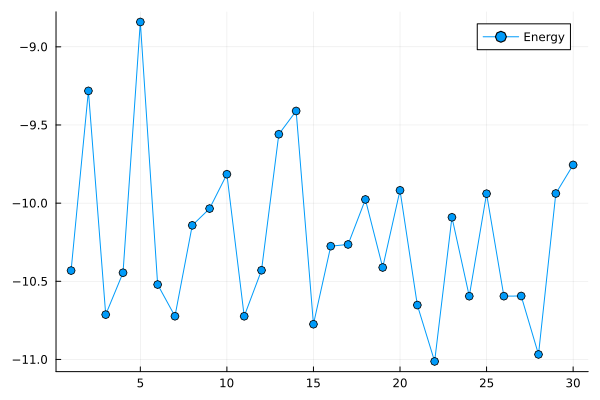

In [81]:
plot(energies, marker=:o, label="Energy")

We can continue with additional iterations with increasing bond dimension and number of sweeps.
At the end we can conclude that:
- the idea of DMRG is clear
- the practice of DMRG is quite more complicated: getting stuck on local minima is quite likely, and a meaningful exploration of the Hilbert space is not trivial to define.


In [64]:
psiRef = copy(bestState)

20-element MPS:
 ((dim=2|id=788|"S=1/2,Site,n=1"), (dim=2|id=265|"Link,l=1"))
 ((dim=2|id=451|"S=1/2,Site,n=2"), (dim=4|id=745|"Link,l=2"), (dim=2|id=265|"Link,l=1"))
 ((dim=2|id=925|"S=1/2,Site,n=3"), (dim=8|id=305|"Link,l=3"), (dim=4|id=745|"Link,l=2"))
 ((dim=2|id=581|"S=1/2,Site,n=4"), (dim=16|id=724|"Link,l=4"), (dim=8|id=305|"Link,l=3"))
 ((dim=2|id=344|"S=1/2,Site,n=5"), (dim=32|id=927|"Link,l=5"), (dim=16|id=724|"Link,l=4"))
 ((dim=2|id=42|"S=1/2,Site,n=6"), (dim=48|id=516|"Link,l=6"), (dim=32|id=927|"Link,l=5"))
 ((dim=2|id=165|"S=1/2,Site,n=7"), (dim=48|id=866|"Link,l=7"), (dim=48|id=516|"Link,l=6"))
 ((dim=2|id=116|"S=1/2,Site,n=8"), (dim=48|id=908|"Link,l=8"), (dim=48|id=866|"Link,l=7"))
 ((dim=2|id=690|"S=1/2,Site,n=9"), (dim=48|id=688|"Link,l=9"), (dim=48|id=908|"Link,l=8"))
 ((dim=2|id=28|"S=1/2,Site,n=10"), (dim=48|id=999|"Link,l=10"), (dim=48|id=688|"Link,l=9"))
 ((dim=2|id=895|"S=1/2,Site,n=11"), (dim=48|id=41|"Link,l=11"), (dim=48|id=999|"Link,l=10"))
 ((dim=2|id=673

In [76]:
norm(S)

1.000000000000003

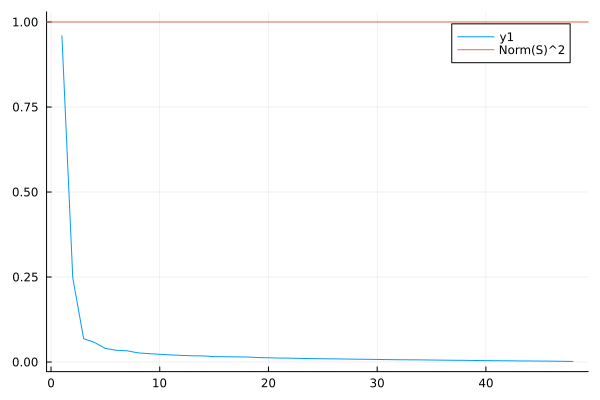

In [78]:
whichSite = 13
orthogonalize!(psiRef, whichSite)
leftindices = [siteind(psiRef, whichSite), linkind(psiRef, whichSite-1)]
U,S,V = svd(psiRef[whichSite], leftindices; cutoff=0)
plot(diag(S))
hline!([norm(S)^2], label="Norm(S)^2")